In [ ]:
import pandas as pd
from datetime import datetime
import numpy as np

In [ ]:
subway1 = pd.read_csv("/content/서울교통공사_역별 시간대별 승하차인원(23.1~23.12) (1).csv", encoding='cp949')
subway2 = pd.read_csv("/content/서울교통공사_역별 시간대별 승하차인원(24.1~24.12).csv", encoding='cp949')
subway3 = pd.read_csv("/content/서울교통공사_역별 일별 시간대별 승하차인원 정보_20221231 (1).csv", encoding='cp949')

In [ ]:
subway2 = subway2.rename(columns={
    '날짜': '수송일자',
    '구분': '승하차구분',
    '06시 이전': '06시이전',
    '06시-07시': '06-07시간대',
    '07시-08시': '07-08시간대',
    '08시-09시': '08-09시간대',
    '09시-10시': '09-10시간대',
    '10시-11시': '10-11시간대',
    '11시-12시': '11-12시간대',
    '12시-13시': '12-13시간대',
    '13시-14시': '13-14시간대',
    '14시-15시': '14-15시간대',
    '15시-16시': '15-16시간대',
    '16시-17시': '16-17시간대',
    '17시-18시': '17-18시간대',
    '18시-19시': '18-19시간대',
    '19시-20시': '19-20시간대',
    '20시-21시': '20-21시간대',
    '21시-22시': '21-22시간대',
    '22시-23시': '22-23시간대',
    '23시-24시': '23-24시간대',
    '24시 이후': '24시이후'
})

In [ ]:
subway3 = subway3.rename(columns={
    '고유역번호(외부역코드)': '역번호'
})

In [ ]:
subway3[subway3["역번호"].astype(str).str.strip() == ""]

,연번,수송일자,호선,역번호,역명,승하차구분,06시이전,06-07시간대,07-08시간대,08-09시간대,...,15-16시간대,16-17시간대,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대,24시이후


In [ ]:
subway3["역번호"] = subway3["역번호"].astype(int)

In [ ]:
#데이터 합치기
subway_data = pd.concat([subway3, subway1, subway2], axis=0)

In [ ]:
subway_data.tail()

,연번,수송일자,호선,역번호,역명,승하차구분,06시이전,06-07시간대,07-08시간대,08-09시간대,...,15-16시간대,16-17시간대,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대,24시이후
199405,199406,2024-12-31,8호선,2826,수진,하차,14,85,152,477,...,355,414,465,468,376,261,248,246,175,68.0
199406,199407,2024-12-31,8호선,2827,모란,승차,80,103,332,400,...,389,537,440,381,247,136,170,140,90,50.0
199407,199408,2024-12-31,8호선,2827,모란,하차,19,109,138,428,...,263,340,340,374,281,193,212,207,141,128.0
199408,199409,2024-12-31,8호선,2828,남위례,승차,44,236,686,811,...,656,469,556,513,285,245,216,213,75,46.0
199409,199410,2024-12-31,8호선,2828,남위례,하차,40,138,306,913,...,377,569,664,781,551,342,276,256,148,69.0


In [ ]:
#승차, 하차 데이터 분리
itaewon_get_on = subway_data[(subway_data['역명'] == '이태원') & (subway_data['승하차구분'] == '승차')]

In [ ]:
#시간대 별로 예측을 진행해야 하므로 시간대를 열 -> 행으로 변경

id_vars =['수송일자', '호선', '역번호', '역명', '승하차구분']
value_vars = ['06시이전', '06-07시간대',
    '07-08시간대', '08-09시간대', '09-10시간대', '10-11시간대', '11-12시간대', '12-13시간대',
    '13-14시간대', '14-15시간대', '15-16시간대', '16-17시간대', '17-18시간대', '18-19시간대',
    '19-20시간대', '20-21시간대', '21-22시간대', '22-23시간대', '23-24시간대', '24시이후']

itaewon_get_on_melt = pd.melt(itaewon_get_on,
                            id_vars=id_vars,
                            value_vars=value_vars,
                            var_name='시간대',
                            value_name='이용객수')

In [ ]:
itaewon_get_on_melt.tail()

,수송일자,호선,역번호,역명,승하차구분,시간대,이용객수
21915,2024-12-27,6호선,2631,이태원,승차,24시이후,293.0
21916,2024-12-28,6호선,2631,이태원,승차,24시이후,0.0
21917,2024-12-29,6호선,2631,이태원,승차,24시이후,1.0
21918,2024-12-30,6호선,2631,이태원,승차,24시이후,152.0
21919,2024-12-31,6호선,2631,이태원,승차,24시이후,645.0


In [ ]:
itaewon_get_on_melt.describe()

,역번호,이용객수
count,21920.0,21769.000000
mean,2631.0,580.303000
std,0.0,362.149209
min,2631.0,0.000000
25%,2631.0,327.000000
50%,2631.0,503.000000
75%,2631.0,808.000000
max,2631.0,7505.000000


In [ ]:
itaewon_get_on_melt.isnull().sum()

,0
수송일자,0
호선,0
역번호,0
역명,0
승하차구분,0
시간대,0
이용객수,151


In [ ]:
#null 값 있는 행 제거
itaewon_get_on_melt = itaewon_get_on_melt.dropna().reset_index(drop=True)

In [ ]:
itaewon_get_on_melt.head()

,수송일자,호선,역번호,역명,승하차구분,시간대,이용객수
0,2022-01-01,6,2631,이태원,승차,06시이전,79.0
1,2022-01-02,6,2631,이태원,승차,06시이전,46.0
2,2022-01-03,6,2631,이태원,승차,06시이전,73.0
3,2022-01-04,6,2631,이태원,승차,06시이전,57.0
4,2022-01-05,6,2631,이태원,승차,06시이전,69.0


In [ ]:
def get_ds(row):
    date = pd.to_datetime(row['수송일자'])
    t = row['시간대']
    if '이전' in t:
        time_str = '05:00:00'
    elif '이후' in t:
        date += pd.Timedelta(days=1)  # 다음 날로 이동
        time_str = '00:00:00'
        print('이후')
    else:
        hour = int(t[:2])
        time_str = f'{hour:02d}:00:00'

    return pd.to_datetime(f"{date.date()} {time_str}")

In [ ]:
itaewon_get_on_melt['ds'] = itaewon_get_on_melt.apply(get_ds, axis=1)

이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이

In [ ]:
itaewon_get_on_melt.isnull().sum()

,0
수송일자,0
호선,0
역번호,0
역명,0
승하차구분,0
시간대,0
이용객수,0
ds,0


In [ ]:
itaewon_get_on_melt.head()

,수송일자,호선,역번호,역명,승하차구분,시간대,이용객수,ds
0,2022-01-01,6,2631,이태원,승차,06시이전,79.0,2022-01-01 05:00:00
1,2022-01-02,6,2631,이태원,승차,06시이전,46.0,2022-01-02 05:00:00
2,2022-01-03,6,2631,이태원,승차,06시이전,73.0,2022-01-03 05:00:00
3,2022-01-04,6,2631,이태원,승차,06시이전,57.0,2022-01-04 05:00:00
4,2022-01-05,6,2631,이태원,승차,06시이전,69.0,2022-01-05 05:00:00


In [ ]:
itaewon_get_on_melt.tail()

,수송일자,호선,역번호,역명,승하차구분,시간대,이용객수,ds
21764,2024-12-27,6호선,2631,이태원,승차,24시이후,293.0,2024-12-28
21765,2024-12-28,6호선,2631,이태원,승차,24시이후,0.0,2024-12-29
21766,2024-12-29,6호선,2631,이태원,승차,24시이후,1.0,2024-12-30
21767,2024-12-30,6호선,2631,이태원,승차,24시이후,152.0,2024-12-31
21768,2024-12-31,6호선,2631,이태원,승차,24시이후,645.0,2025-01-01


In [ ]:
itaewon_get_on_melt[itaewon_get_on_melt["ds"].dt.hour == 0]

,수송일자,호선,역번호,역명,승하차구분,시간대,이용객수,ds
20824,2022-06-01,6,2631,이태원,승차,24시이후,1.0,2022-06-02
20825,2022-06-02,6,2631,이태원,승차,24시이후,0.0,2022-06-03
20826,2022-06-03,6,2631,이태원,승차,24시이후,1.0,2022-06-04
20827,2022-06-04,6,2631,이태원,승차,24시이후,0.0,2022-06-05
20828,2022-06-05,6,2631,이태원,승차,24시이후,2.0,2022-06-06
...,...,...,...,...,...,...,...,...
21764,2024-12-27,6호선,2631,이태원,승차,24시이후,293.0,2024-12-28
21765,2024-12-28,6호선,2631,이태원,승차,24시이후,0.0,2024-12-29
21766,2024-12-29,6호선,2631,이태원,승차,24시이후,1.0,2024-12-30
21767,2024-12-30,6호선,2631,이태원,승차,24시이후,152.0,2024-12-31


In [ ]:
itaewon_get_on_melt = itaewon_get_on_melt.rename(columns={
    '이용객수': 'y'
})

In [ ]:
df_prophet = itaewon_get_on_melt[['ds', 'y']].copy()

In [ ]:
df_prophet['hour'] = df_prophet['ds'].dt.hour #시간
df_prophet['dayofweek'] = df_prophet['ds'].dt.day_of_week #요일
df_prophet['month'] = df_prophet['ds'].dt.month #월
df_prophet['is_weekend'] = df_prophet['ds'].dt.dayofweek.isin([5, 6]).astype(int) #주말여부
df_prophet['is_halloween'] = df_prophet['ds'].apply(lambda x: 1 if x.month == 10 and x.day == 31 else 0) #할로윈 여부

In [ ]:
df_prophet

,ds,y,hour,dayofweek,month,is_weekend,is_halloween
0,2022-01-01 05:00:00,79.0,5,5,1,1,0
1,2022-01-02 05:00:00,46.0,5,6,1,1,0
2,2022-01-03 05:00:00,73.0,5,0,1,0,0
3,2022-01-04 05:00:00,57.0,5,1,1,0,0
4,2022-01-05 05:00:00,69.0,5,2,1,0,0
...,...,...,...,...,...,...,...
21764,2024-12-28 00:00:00,293.0,0,5,12,1,0
21765,2024-12-29 00:00:00,0.0,0,6,12,1,0
21766,2024-12-30 00:00:00,1.0,0,0,12,0,0
21767,2024-12-31 00:00:00,152.0,0,1,12,0,0


In [ ]:
df_prophet = pd.get_dummies(df_prophet, columns=['dayofweek', 'month', 'hour'], drop_first=True, dtype=int)

In [ ]:
df_prophet.head()

,ds,y,is_weekend,is_halloween,dayofweek_1,dayofweek_2,dayofweek_3,dayofweek_4,dayofweek_5,dayofweek_6,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,2022-01-01 05:00:00,79.0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2022-01-02 05:00:00,46.0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,2022-01-03 05:00:00,73.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2022-01-04 05:00:00,57.0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2022-01-05 05:00:00,69.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_prophet.columns

Index(['ds', 'y', 'is_weekend', 'is_halloween', 'dayofweek_1', 'dayofweek_2',
       'dayofweek_3', 'dayofweek_4', 'dayofweek_5', 'dayofweek_6', 'month_2',
       'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8',
       'month_9', 'month_10', 'month_11', 'month_12', 'hour_5', 'hour_6',
       'hour_7', 'hour_8', 'hour_9', 'hour_10', 'hour_11', 'hour_12',
       'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18',
       'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23'],
      dtype='object')

In [ ]:
df_prophet.dtypes

,0
ds,datetime64[ns]
y,float64
is_weekend,int64
is_halloween,int64
dayofweek_1,int64
dayofweek_2,int64
dayofweek_3,int64
dayofweek_4,int64
dayofweek_5,int64
dayofweek_6,int64


In [ ]:
from prophet import Prophet

# Prophet 모델 생성 및 학습

#dail, weekly 패턴 학습하도록 설정(지하철 특성 반영)
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.1
)

for col in df_prophet.columns:
    if col.startswith('month_') or col.startswith('dayofweek_') or col.startswith('hour_'):
        model.add_regressor(col)
model.add_regressor('is_weekend')
model.add_regressor('is_halloween')
# 한국 공휴일 추가
model.add_country_holidays(country_name='KR')

In [ ]:
#모델 학습
model.fit(df_prophet)

In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics
df_cv = cross_validation(model, initial='365 days', period='7 days', horizon='24 hours')

INFO:prophet:Making 105 forecasts with cutoffs between 2023-01-03 00:00:00 and 2024-12-31 00:00:00


  0%|          | 0/105 [00:00<?, ?it/s]

In [ ]:
df_cv

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2023-01-03 05:00:00,402.624031,65.147976,736.767632,81.0,2023-01-03
1,2023-01-03 06:00:00,330.439611,-26.500066,662.886796,145.0,2023-01-03
2,2023-01-03 07:00:00,367.761916,40.608191,710.459482,305.0,2023-01-03
3,2023-01-03 08:00:00,476.556995,125.800748,805.826393,517.0,2023-01-03
4,2023-01-03 09:00:00,380.058810,15.471834,715.127317,385.0,2023-01-03
...,...,...,...,...,...,...
2095,2024-12-31 20:00:00,761.832552,500.659026,1031.078072,853.0,2024-12-31
2096,2024-12-31 21:00:00,836.030137,592.451883,1099.740550,916.0,2024-12-31
2097,2024-12-31 22:00:00,783.384585,527.966902,1041.311107,953.0,2024-12-31
2098,2024-12-31 23:00:00,505.979828,260.290636,756.432448,628.0,2024-12-31


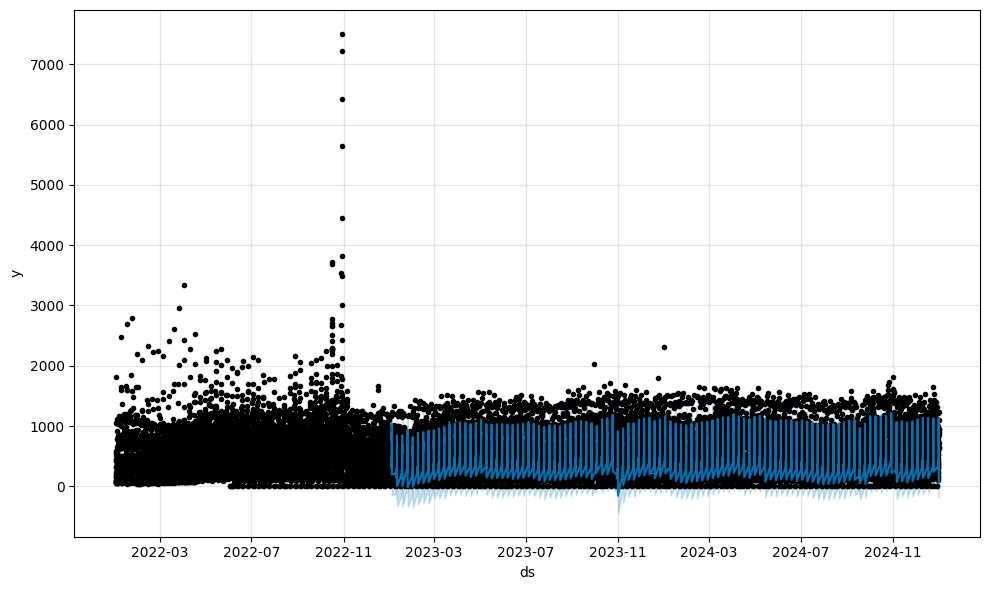

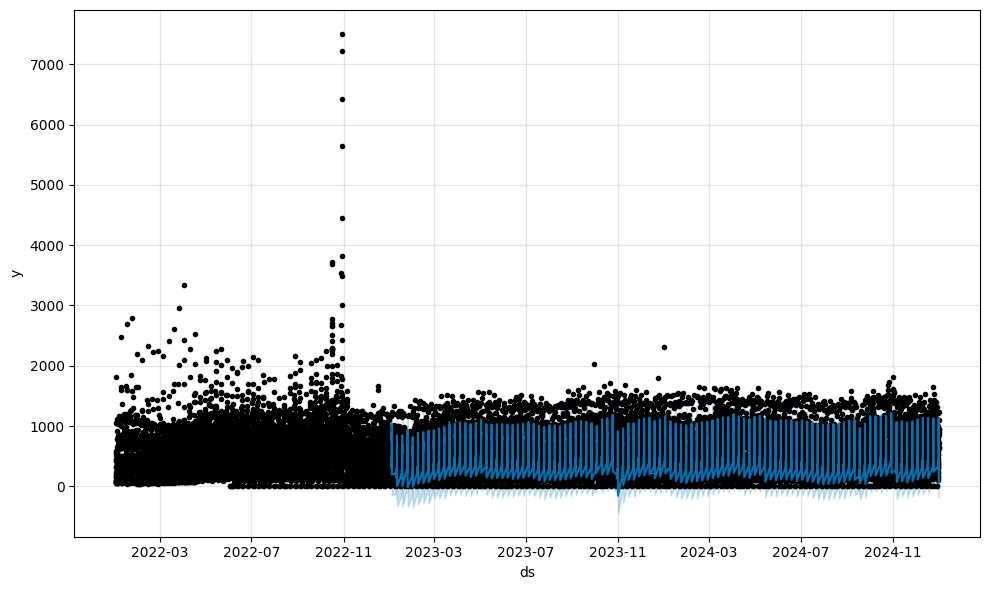

In [ ]:
model.plot(df_cv)

In [ ]:
# 성능 지표 확인
df_p = performance_metrics(df_cv)

df_p

INFO:prophet:Skipping MAPE because y close to 0


,horizon,mse,rmse,mae,mdape,smape,coverage
0,0 days 06:00:00,30930.713835,175.871299,158.065088,1.148181,0.722163,0.938095
1,0 days 07:00:00,9234.420608,96.095893,78.635759,0.284320,0.323956,0.995238
2,0 days 08:00:00,9476.686936,97.348276,73.177604,0.146649,0.194346,0.995238
3,0 days 09:00:00,10583.345052,102.875386,77.976730,0.139976,0.195275,0.995238
4,0 days 10:00:00,5062.514070,71.151346,53.052261,0.117020,0.169768,1.000000
5,0 days 11:00:00,3173.310274,56.332142,43.151702,0.105314,0.150115,1.000000
6,0 days 12:00:00,3108.463456,55.753596,42.235801,0.092635,0.127221,1.000000
7,0 days 13:00:00,3415.941098,58.446053,44.987457,0.092682,0.116384,1.000000
8,0 days 14:00:00,4144.919937,64.381053,51.773019,0.097233,0.115990,1.000000
9,0 days 15:00:00,5158.605376,71.823432,57.654834,0.085933,0.108336,1.000000


In [ ]:
df_p.tail()

,horizon,mse,rmse,mae,mdape,smape,coverage
14,0 days 20:00:00,18124.308316,134.626551,109.443260,0.113592,0.135451,0.976190
15,0 days 21:00:00,11360.475604,106.585532,79.889456,0.084585,0.107197,0.971429
16,0 days 22:00:00,18765.834673,136.988447,107.867930,0.136910,0.150504,0.966667
17,0 days 23:00:00,22551.081557,150.170175,122.843080,0.237916,0.231622,0.980952
18,1 days 00:00:00,15946.069477,126.277747,93.591245,0.366582,0.452910,0.985714


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


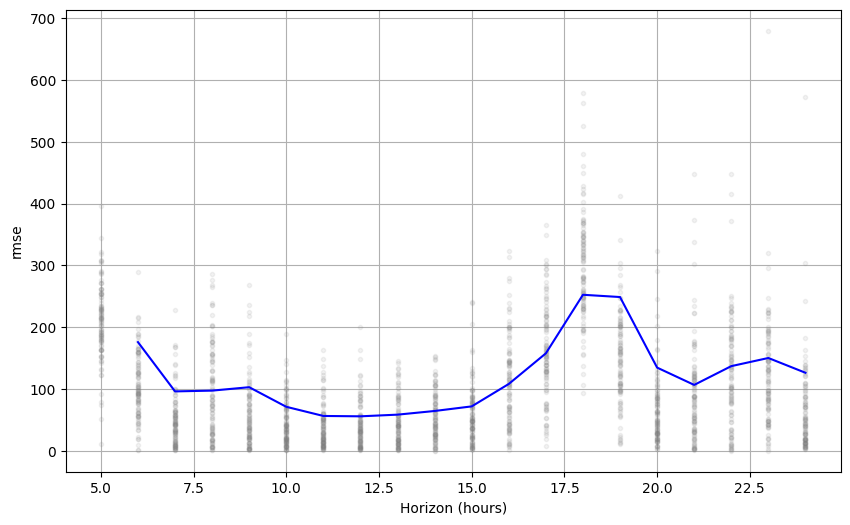

In [ ]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='rmse')

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


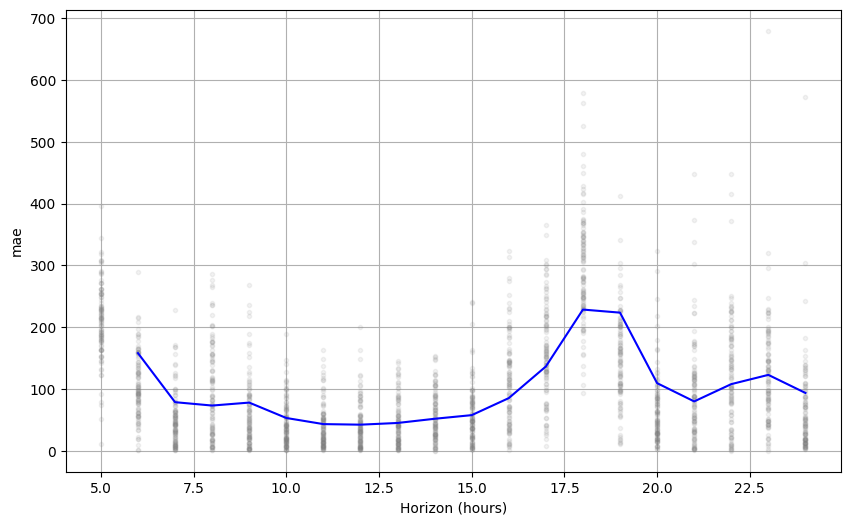

In [ ]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='mae')

In [ ]:
df_p.describe()

,horizon,mse,rmse,mae,mdape,smape,coverage
count,19,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,0 days 15:00:00,17541.208982,119.574074,98.324963,0.203227,0.210432,0.954887
std,0 days 05:37:38.331619360,17836.403409,58.510089,55.460728,0.240814,0.150289,0.090216
min,0 days 06:00:00,3108.463456,55.753596,42.235801,0.084585,0.107197,0.690476
25%,0 days 10:30:00,5110.559723,71.487389,55.353547,0.096597,0.122809,0.969048
50%,0 days 15:00:00,11360.475604,106.585532,79.889456,0.136910,0.152944,0.985714
75%,0 days 19:30:00,20658.458115,143.579311,116.143170,0.189397,0.212814,1.000000
max,1 days 00:00:00,63762.116756,252.511617,228.565827,1.148181,0.722163,1.000000


In [ ]:
df_p.to_csv("승차_통계.csv", index=False)

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(df_cv["y"], df_cv["yhat"])

print(f"Cross Validation R²: {r2:.4f}")

Cross Validation R²: 0.8290


In [ ]:
import joblib
joblib.dump(model, 'get_on_model.pkl')

['get_on_model.pkl']

#2025년 데이터로 테스트를 해봅시다..

In [ ]:

subway_2025 = pd.read_csv("/content/서울교통공사_역별 일별 시간대별 승하차인원_20251231.csv", encoding='cp949')

In [ ]:
subway_2025.head()

,연번,수송일자,호선,역번호,역명,승하차구분,06시이전,06-07시간대,07-08시간대,08-09시간대,...,15-16시간대,16-17시간대,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대,24시이후
0,1.0,2025-01-01,1호선,150.0,서울역,승차,411.0,317.0,419.0,733.0,...,3699.0,3694.0,3727.0,3252.0,2925.0,2210.0,2465.0,1555.0,838.0,29.0
1,2.0,2025-01-01,1호선,150.0,서울역,하차,261.0,715.0,941.0,1042.0,...,3061.0,3219.0,3128.0,2591.0,2271.0,2031.0,1553.0,945.0,455.0,130.0
2,3.0,2025-01-01,1호선,151.0,시청,승차,62.0,70.0,122.0,216.0,...,1192.0,1280.0,1276.0,1195.0,926.0,856.0,757.0,444.0,201.0,1.0
3,4.0,2025-01-01,1호선,151.0,시청,하차,70.0,271.0,296.0,479.0,...,1176.0,881.0,775.0,592.0,392.0,289.0,264.0,146.0,76.0,9.0
4,5.0,2025-01-01,1호선,152.0,종각,승차,557.0,211.0,159.0,197.0,...,1284.0,1303.0,1520.0,1490.0,1367.0,1355.0,1168.0,885.0,267.0,9.0


In [49]:
itaewon_2025 = subway_2025[(subway_2025['역명'] == '이태원') & (subway_2025['승하차구분'] == '승차')]

In [50]:
itaewon_2025_melt = pd.melt(itaewon_2025,
                            id_vars=id_vars,
                            value_vars=value_vars,
                            var_name='시간대',
                            value_name='이용객수')

In [51]:
itaewon_2025_melt.head()

,수송일자,호선,역번호,역명,승하차구분,시간대,이용객수
0,2025-01-01,6호선,2631.0,이태원,승차,06시이전,2251.0
1,2025-01-02,6호선,2631.0,이태원,승차,06시이전,88.0
2,2025-01-03,6호선,2631.0,이태원,승차,06시이전,111.0
3,2025-01-04,6호선,2631.0,이태원,승차,06시이전,459.0
4,2025-01-05,6호선,2631.0,이태원,승차,06시이전,806.0


In [52]:
itaewon_2025_melt.isnull().sum()

,0
수송일자,0
호선,0
역번호,0
역명,0
승하차구분,0
시간대,0
이용객수,0


In [53]:
itaewon_2025_melt['ds'] = itaewon_2025_melt.apply(get_ds, axis=1)

이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이

In [54]:
itaewon_2025_melt = itaewon_2025_melt.rename(columns={
    '이용객수': 'y'
})

In [55]:
df_prophet_2025 = itaewon_2025_melt[['ds', 'y']].copy()

In [56]:
df_prophet_2025['hour'] = df_prophet_2025['ds'].dt.hour #시간
df_prophet_2025['dayofweek'] = df_prophet_2025['ds'].dt.day_of_week #요일
df_prophet_2025['month'] = df_prophet_2025['ds'].dt.month #월
df_prophet_2025['is_weekend'] = df_prophet_2025['ds'].dt.dayofweek.isin([5, 6]).astype(int) #주말여부
df_prophet_2025['is_halloween'] = df_prophet_2025['ds'].apply(lambda x: 1 if x.month == 10 and x.day == 31 else 0) #할로윈 여부

In [57]:
df_prophet_2025

,ds,y,hour,dayofweek,month,is_weekend,is_halloween
0,2025-01-01 05:00:00,2251.0,5,2,1,0,0
1,2025-01-02 05:00:00,88.0,5,3,1,0,0
2,2025-01-03 05:00:00,111.0,5,4,1,0,0
3,2025-01-04 05:00:00,459.0,5,5,1,1,0
4,2025-01-05 05:00:00,806.0,5,6,1,1,0
...,...,...,...,...,...,...,...
7295,2025-12-28 00:00:00,0.0,0,6,12,1,0
7296,2025-12-29 00:00:00,1.0,0,0,12,0,0
7297,2025-12-30 00:00:00,113.0,0,1,12,0,0
7298,2025-12-31 00:00:00,177.0,0,2,12,0,0


In [58]:
df_prophet_2025 = pd.get_dummies(df_prophet_2025, columns=['dayofweek', 'month', 'hour'], drop_first=True, dtype=int)

In [59]:
df_prophet_2025

,ds,y,is_weekend,is_halloween,dayofweek_1,dayofweek_2,dayofweek_3,dayofweek_4,dayofweek_5,dayofweek_6,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,2025-01-01 05:00:00,2251.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2025-01-02 05:00:00,88.0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2025-01-03 05:00:00,111.0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2025-01-04 05:00:00,459.0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,2025-01-05 05:00:00,806.0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7295,2025-12-28 00:00:00,0.0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7296,2025-12-29 00:00:00,1.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7297,2025-12-30 00:00:00,113.0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7298,2025-12-31 00:00:00,177.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [60]:
future = df_prophet_2025.drop(columns='y')

In [61]:
future.columns

Index(['ds', 'is_weekend', 'is_halloween', 'dayofweek_1', 'dayofweek_2',
       'dayofweek_3', 'dayofweek_4', 'dayofweek_5', 'dayofweek_6', 'month_2',
       'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8',
       'month_9', 'month_10', 'month_11', 'month_12', 'hour_5', 'hour_6',
       'hour_7', 'hour_8', 'hour_9', 'hour_10', 'hour_11', 'hour_12',
       'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18',
       'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23'],
      dtype='object')

###2025년 전체 예측

In [62]:
forecast = model.predict(future)

In [63]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'Alternative holiday for Buddha's Birthday',
       'Alternative holiday for Buddha's Birthday_lower',
       'Alternative holiday for Buddha's Birthday_upper',
       'Alternative holiday for Children's Day',
       ...
       'weekly', 'weekly_lower', 'weekly_upper', 'yearly', 'yearly_lower',
       'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower',
       'multiplicative_terms_upper', 'yhat'],
      dtype='object', length=220)

In [64]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Alternative holiday for Buddha's Birthday,Alternative holiday for Buddha's Birthday_lower,Alternative holiday for Buddha's Birthday_upper,Alternative holiday for Children's Day,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
7295,2025-12-31 20:00:00,464.635447,-230.365739,1997.474806,-688.615674,1516.125456,0.0,0.0,0.0,0.0,...,-209.475454,-209.475454,-209.475454,43.933483,43.933483,43.933483,0.0,0.0,0.0,912.010532
7296,2025-12-31 21:00:00,464.649246,-209.411889,2088.675999,-688.810229,1516.432323,0.0,0.0,0.0,0.0,...,-210.200491,-210.200491,-210.200491,43.891263,43.891263,43.891263,0.0,0.0,0.0,990.367333
7297,2025-12-31 22:00:00,464.663046,-218.355910,2026.786486,-689.004784,1516.739190,0.0,0.0,0.0,0.0,...,-210.692894,-210.692894,-210.692894,43.849121,43.849121,43.849121,0.0,0.0,0.0,942.351592
7298,2025-12-31 23:00:00,464.676845,-512.782859,1725.257621,-689.199339,1517.044030,0.0,0.0,0.0,0.0,...,-210.971718,-210.971718,-210.971718,43.807057,43.807057,43.807057,0.0,0.0,0.0,669.860885
7299,2026-01-01 00:00:00,464.690645,-979.379908,1254.319688,-689.393893,1517.325529,0.0,0.0,0.0,0.0,...,-211.057537,-211.057537,-211.057537,43.765075,43.765075,43.765075,0.0,0.0,0.0,159.164081


In [65]:
result = df_prophet_2025[['ds', 'y']].merge(forecast[['ds', 'yhat']],on='ds')

In [66]:
result.head()

,ds,y,yhat
0,2025-01-01 05:00:00,2251.0,300.763202
1,2025-01-02 05:00:00,88.0,311.568172
2,2025-01-03 05:00:00,111.0,332.598320
3,2025-01-04 05:00:00,459.0,337.691960
4,2025-01-05 05:00:00,806.0,416.767268


In [67]:
r2 = r2_score(result["y"], result["yhat"])
r2

0.6658563164771338

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# MAE
mae = mean_absolute_error(result['y'], result['yhat'])

# RMSE
rmse = np.sqrt(mean_squared_error(result['y'], result['yhat']))

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE : 169.700
RMSE: 215.661


###2025년 중에 하루 예측

In [69]:
test_one_day = df_prophet_2025[df_prophet_2025['ds'].dt.date == pd.to_datetime('2025-01-15').date()]

In [70]:
test_one_day

,ds,y,is_weekend,is_halloween,dayofweek_1,dayofweek_2,dayofweek_3,dayofweek_4,dayofweek_5,dayofweek_6,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
14,2025-01-15 05:00:00,125.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
379,2025-01-15 06:00:00,137.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
744,2025-01-15 07:00:00,279.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1109,2025-01-15 08:00:00,424.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1474,2025-01-15 09:00:00,448.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1839,2025-01-15 10:00:00,381.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2204,2025-01-15 11:00:00,350.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2569,2025-01-15 12:00:00,346.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2934,2025-01-15 13:00:00,379.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3299,2025-01-15 14:00:00,458.0,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [71]:
future_one_day = test_one_day.drop(columns='y')

In [72]:
future_one_day.columns

Index(['ds', 'is_weekend', 'is_halloween', 'dayofweek_1', 'dayofweek_2',
       'dayofweek_3', 'dayofweek_4', 'dayofweek_5', 'dayofweek_6', 'month_2',
       'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8',
       'month_9', 'month_10', 'month_11', 'month_12', 'hour_5', 'hour_6',
       'hour_7', 'hour_8', 'hour_9', 'hour_10', 'hour_11', 'hour_12',
       'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18',
       'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23'],
      dtype='object')

In [73]:
forecast_one_day = model.predict(future_one_day)

In [74]:
forecast_one_day.tail(24)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Alternative holiday for Buddha's Birthday,Alternative holiday for Buddha's Birthday_lower,Alternative holiday for Buddha's Birthday_upper,Alternative holiday for Children's Day,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-01-15 00:00:00,348.442524,-147.531138,361.657096,348.442524,348.442524,0.0,0.0,0.0,0.0,...,-141.034008,-141.034008,-141.034008,35.759762,35.759762,35.759762,0.0,0.0,0.0,110.751763
1,2025-01-15 05:00:00,348.511522,60.923602,610.942439,348.511522,348.511522,0.0,0.0,0.0,0.0,...,-165.825797,-165.825797,-165.825797,35.660672,35.660672,35.660672,0.0,0.0,0.0,328.140950
2,2025-01-15 06:00:00,348.525321,21.887587,500.543092,348.525321,348.525321,0.0,0.0,0.0,0.0,...,-170.456809,-170.456809,-170.456809,35.640493,35.640493,35.640493,0.0,0.0,0.0,275.554190
3,2025-01-15 07:00:00,348.539121,54.351472,556.227909,348.539121,348.539121,0.0,0.0,0.0,0.0,...,-174.913329,-174.913329,-174.913329,35.620190,35.620190,35.620190,0.0,0.0,0.0,304.742602
4,2025-01-15 08:00:00,348.552921,144.338180,659.944493,348.552921,348.552921,0.0,0.0,0.0,0.0,...,-179.170472,-179.170472,-179.170472,35.599764,35.599764,35.599764,0.0,0.0,0.0,409.483987
5,2025-01-15 09:00:00,348.566720,84.788323,600.517121,348.566720,348.566720,0.0,0.0,0.0,0.0,...,-183.205626,-183.205626,-183.205626,35.579213,35.579213,35.579213,0.0,0.0,0.0,343.586323
6,2025-01-15 10:00:00,348.580520,40.195675,558.496625,348.580520,348.580520,0.0,0.0,0.0,0.0,...,-186.998780,-186.998780,-186.998780,35.558536,35.558536,35.558536,0.0,0.0,0.0,296.634105
7,2025-01-15 11:00:00,348.594320,81.959170,577.203600,348.594320,348.594320,0.0,0.0,0.0,0.0,...,-190.532805,-190.532805,-190.532805,35.537731,35.537731,35.537731,0.0,0.0,0.0,330.451143
8,2025-01-15 12:00:00,348.608119,149.069394,653.361845,348.608119,348.608119,0.0,0.0,0.0,0.0,...,-193.793679,-193.793679,-193.793679,35.516799,35.516799,35.516799,0.0,0.0,0.0,390.048327
9,2025-01-15 13:00:00,348.621919,200.503624,683.612312,348.621919,348.621919,0.0,0.0,0.0,0.0,...,-196.770666,-196.770666,-196.770666,35.495738,35.495738,35.495738,0.0,0.0,0.0,447.988233


In [75]:
result_one_day = test_one_day[['ds', 'y']].merge(forecast_one_day[['ds', 'yhat']],on='ds')

In [76]:
r2 = r2_score(result_one_day["y"], result_one_day["yhat"])
r2

0.8762990083103611

In [77]:
# MAE
mae = mean_absolute_error(result_one_day['y'], result_one_day['yhat'])

# RMSE
rmse = np.sqrt(mean_squared_error(result_one_day['y'], result_one_day['yhat']))

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE : 92.442
RMSE: 114.819


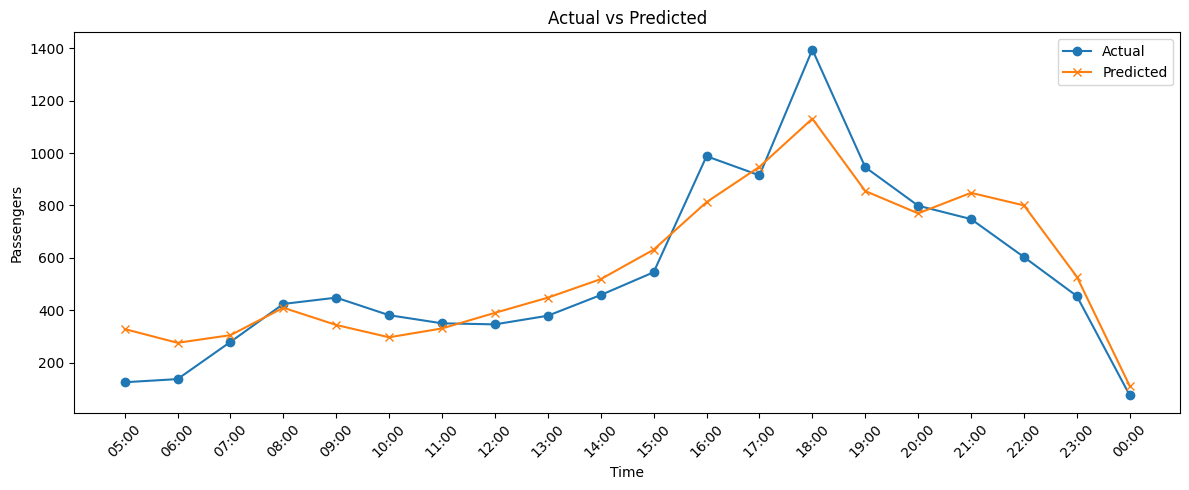

In [78]:
import matplotlib.pyplot as plt

result_one_day['hour'] = result_one_day['ds'].dt.strftime('%H:%M')


plt.figure(figsize=(12, 5))
plt.plot(result_one_day['hour'], result_one_day['y'], marker='o', label='Actual')
plt.plot(result_one_day['hour'], result_one_day['yhat'], marker='x', label='Predicted')
plt.xlabel('Time')
plt.ylabel('Passengers')
plt.title('Actual vs Predicted')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [79]:
result_one_day

,ds,y,yhat,hour
0,2025-01-15 05:00:00,125.0,328.140950,05:00
1,2025-01-15 06:00:00,137.0,275.554190,06:00
2,2025-01-15 07:00:00,279.0,304.742602,07:00
3,2025-01-15 08:00:00,424.0,409.483987,08:00
4,2025-01-15 09:00:00,448.0,343.586323,09:00
5,2025-01-15 10:00:00,381.0,296.634105,10:00
6,2025-01-15 11:00:00,350.0,330.451143,11:00
7,2025-01-15 12:00:00,346.0,390.048327,12:00
8,2025-01-15 13:00:00,379.0,447.988233,13:00
9,2025-01-15 14:00:00,458.0,518.755369,14:00
